# Lasso model 

In [32]:

import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [38]:
ALL_Data =  pd.read_csv("All_features.csv",index_col="Date",parse_dates=["Date"]).dropna()
ALL_Data["Traget_HDFC"] = ALL_Data["HDFCBANK"].shift(-1)

In [46]:
ALL_Data.drop("HDFCBANK" ,axis =1,inplace =  True)

In [80]:
ALL_Data.dropna(inplace =True)

In [82]:
X = ALL_Data[['NIFTY50', 'BANKNIFTY', 'SENSEX', 'INDIA_VIX', 'USDINR', 'SP500',
       'NASDAQ100', 'DOWJONES', 'NIKKEI225', 'HANGSENG', 'GOLD', 'BRENT_OIL',
       'ICICIBANK', 'SBIN', 'AXISBANK', 'KOTAKBANK']]

In [84]:
Y  = ALL_Data["Traget_HDFC"]

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [88]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 10)
lasso.fit(X_train, Y_train)

Lasso(alpha=10)

In [94]:
#Step 5: Get Intercept and Coeff for Lasso Regression
coefficients = lasso.coef_
coefficients

# Intercept
intercept = lasso.intercept_
intercept

# Create DataFrame
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})


In [96]:
coeff_df

,Feature,Coefficient
0,NIFTY50,-1.226662
1,BANKNIFTY,0.017013
2,SENSEX,-0.888853
3,INDIA_VIX,-0.138567
4,USDINR,0.000000
5,SP500,-0.196681
6,NASDAQ100,0.040399
7,DOWJONES,0.032828
8,NIKKEI225,0.008264
9,HANGSENG,-0.130296


In [98]:
# Step 6: Predict using Lasso Regression
y_pred = lasso.predict(X_test)
y_pred

array([ 742.20277774,  556.66040961,  383.53589029, 1122.82291947,
        886.01833892,  773.32516682,  687.82592169,  886.80270123,
       1155.69167754,  468.29081627,  885.91830517,  625.59453395,
        663.14315539,  589.3161586 ,  513.1835253 ,  408.64761792,
        497.38315765,  632.08040768,  488.74290108,  604.58288527,
        632.90929551,  788.59353047,  695.3013258 ,  477.91090255,
        455.47308238, 1089.50159252,  838.2893952 ,  424.09118643,
       1196.07960472,  499.18245252,  812.66475091, 1147.79367819,
        534.49401386,  425.18947751,  512.28783206,  750.5349175 ,
        816.20604057,  577.80653885,  606.535842  ,  599.04837946,
        510.05564345, 1051.46756004, 1207.17037972,  496.29484386,
        456.12403057,  531.07264721,  438.94328279,  506.80798341,
        502.69465303,  519.97524302,  669.01641184,  737.59256355,
        546.91529881,  559.01389774,  491.80439938, 1070.73131031,
        582.13908464,  868.56285591,  455.98869113,  550.35230

In [100]:
# Step 7: Create a dataframe with Actual and Predicted Values
df_result = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred})
df_result


,Actual,Predicted
Date,,
2022-04-27,776.557556,742.202778
2018-03-07,517.742554,556.660410
2016-02-17,388.419128,383.535890
2025-08-19,1080.199951,1122.822919
2023-02-10,856.830017,886.018339
...,...,...
2019-03-28,761.470947,709.986448
2019-06-21,758.735779,688.562115
2015-07-30,559.624207,493.277672


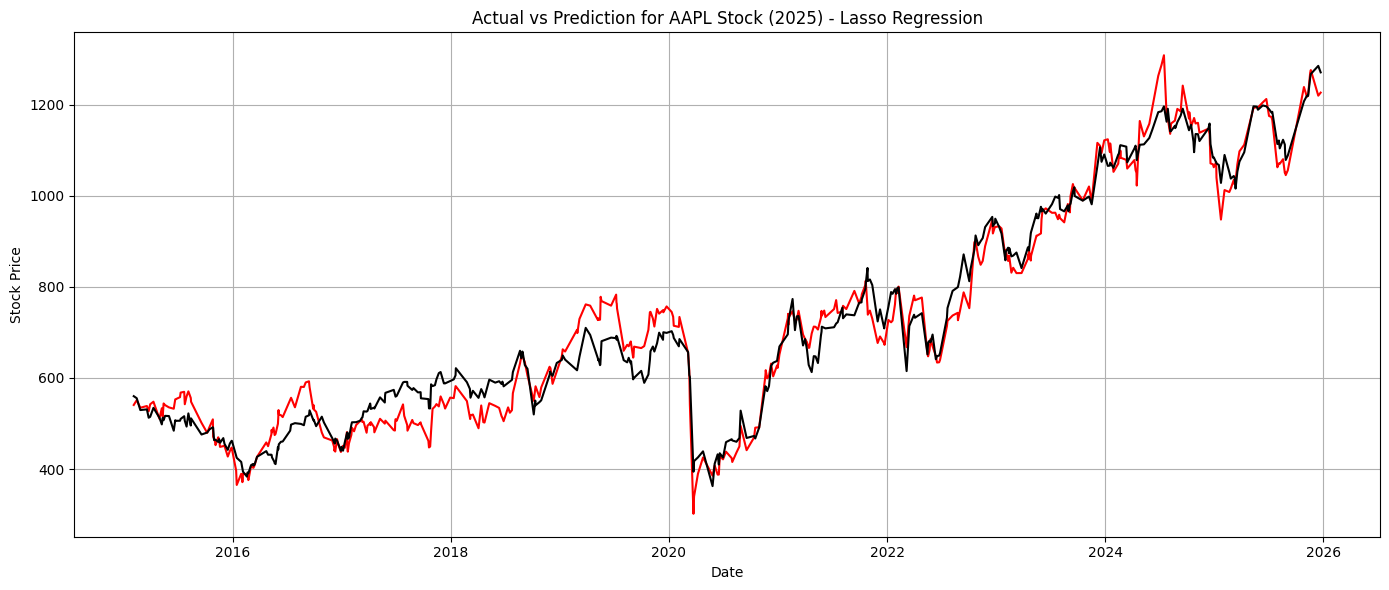

In [114]:
import matplotlib.pyplot as plt
df_result = df_result.sort_index()
plt.figure(figsize = (14,6))
plt.plot(df_result.index, df_result['Actual'], label = 'Actual', color ='red')
plt.plot(df_result.index, df_result['Predicted'], label = 'Predicted', color  ='Black')
plt.title("Actual vs Prediction for AAPL Stock (2025) - Lasso Regression")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.grid(True)
plt.tight_layout()
plt.show()


In [116]:
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(Y_test, y_pred)
print("R square", r2)
mse = mean_squared_error(Y_test, y_pred)
print("mse",mse)
rmse = np.sqrt(mse)
print("rmse", rmse)


R square 0.9669461244915172
mse 1960.1394546934227
rmse 44.273462194563265
